# Практика 4 Оптимизация Wine
Продолжаю практику 3 на том же разделении данных. Проверяю SMOTE, кривые обучения и GridSearchCV. В задании требуется прирост macro-F1 на 5–10%, но исходный тестовый результат уже 1,0. Выше 1,0 эта метрика быть не может. Поэтому я показываю реальные результаты и не создаю искусственно плохую исходную модель.

In [1]:
from pathlib import Path
import platform
print("Python:", platform.python_version())
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# При запуске из корня проекта или из папки МО находятся одни и те же данные.
BASE = Path.cwd() if (Path.cwd() / 'data').is_dir() else Path.cwd() / 'МО'
if not (BASE / 'data').is_dir():
    raise FileNotFoundError('Откройте ноутбук из папки МО или из папки Работы Николая.')
for folder in ['figures', 'results', 'models']:
    (BASE / folder).mkdir(exist_ok=True)
RANDOM_STATE = 42
plt.rcParams.update({'font.family': 'DejaVu Sans', 'figure.dpi': 110})

def save_plot(name):
    # Сохраняю тот же график, который показывается в ноутбуке.
    plt.tight_layout()
    plt.savefig(BASE / 'figures' / name, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

def save_json(name, data):
    (BASE / 'results' / name).write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding='utf-8')

Python: 3.10.20


In [2]:
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, learning_curve, cross_val_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
with open(BASE/'models'/'practice3.pkl','rb') as f:
    previous=pickle.load(f)
X_train,X_test=previous['X_train'],previous['X_test']
y_train,y_test=previous['y_train'],previous['y_test']
base=previous['model']
balanced=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
# SMOTE использует расстояния. Поэтому сначала масштабирую признаки.
# Pipeline создаёт синтетические примеры только в тренировочной части каждого блока CV.
smote_model=ImbPipeline([('scaler',StandardScaler()),
    ('smote',SMOTE(random_state=42,k_neighbors=3)),
    ('model',RandomForestClassifier(n_estimators=100,random_state=42))])
cv=StratifiedKFold(n_splits=3,shuffle=True,random_state=42)
rows=[]
for name,model in [('Базовая',base),('+ class_weight',balanced),('+ SMOTE',smote_model)]:
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    scores=cross_val_score(clone(model),X_train,y_train,cv=cv,scoring='f1_macro')
    rows.append({'Шаг':name,'Macro-F1 test':f1_score(y_test,pred,average='macro'),
                 'Macro-F1 CV':scores.mean(),'SD CV':scores.std()})
    print(name)
    print(classification_report(y_test,pred))

Базовая
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



+ class_weight
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



+ SMOTE
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



## Кривые обучения
Сравниваю качество на train и на validation при разных размерах обучающей части. Большой устойчивый разрыв указывает на переобучение. Эти кривые строю для модели с class_weight, чтобы проверить её поведение на небольшом наборе данных.

,Размер train,Train,Validation
0,24,1.0,0.930894
1,38,1.0,0.961320
2,53,1.0,0.975946
3,67,1.0,0.975946
4,82,1.0,0.976195


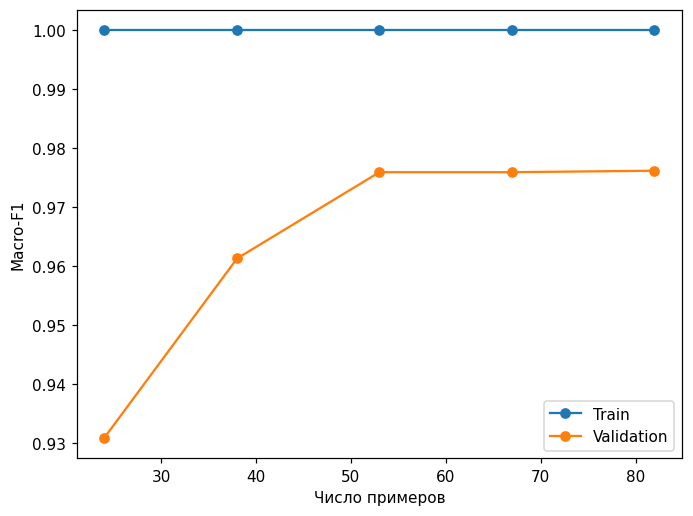

Разрыв на максимальном размере: 0.0238


In [3]:
sizes,train_scores,val_scores=learning_curve(balanced,X_train,y_train,cv=cv,
    scoring='f1_macro',train_sizes=np.linspace(0.3,1.0,5),shuffle=True,random_state=42)
curve=pd.DataFrame({'Размер train':sizes,'Train':train_scores.mean(axis=1),'Validation':val_scores.mean(axis=1)})
display(curve)
curve.to_csv(BASE/'results'/'practice4_learning_curve.csv',index=False)
plt.plot(sizes,train_scores.mean(axis=1),'o-',label='Train')
plt.plot(sizes,val_scores.mean(axis=1),'o-',label='Validation')
plt.xlabel('Число примеров');plt.ylabel('Macro-F1');plt.legend()
save_plot('p4_learning_curve.png')
print('Разрыв на максимальном размере:',round(curve.iloc[-1]['Train']-curve.iloc[-1]['Validation'],4))

Лучшие параметры: {'model__max_depth': 5, 'model__n_estimators': 50}
Средний macro-F1 на CV: 0.9846
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



,Шаг,Macro-F1 test,Macro-F1 CV,SD CV
0,Базовая,1.0,0.976195,0.019122
1,+ class_weight,1.0,0.984604,0.010955
2,+ SMOTE,1.0,0.976195,0.019122
3,+ GridSearchCV,1.0,0.984604,0.010955


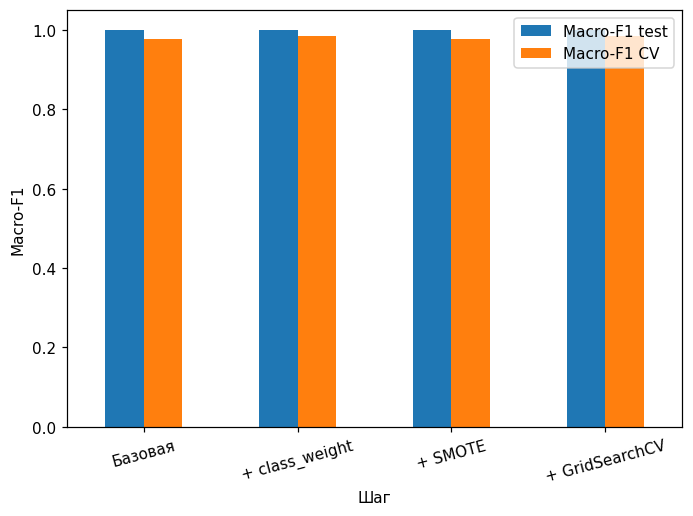

In [4]:
grid=GridSearchCV(smote_model,{'model__max_depth':[5,10,None],
    'model__n_estimators':[50,100]},scoring='f1_macro',cv=cv,n_jobs=1)
grid.fit(X_train,y_train)
pred=grid.predict(X_test)
print('Лучшие параметры:',grid.best_params_)
print('Средний macro-F1 на CV:',round(grid.best_score_,4))
print(classification_report(y_test,pred))
scores=cross_val_score(clone(grid.best_estimator_),X_train,y_train,cv=cv,scoring='f1_macro')
rows.append({'Шаг':'+ GridSearchCV','Macro-F1 test':f1_score(y_test,pred,average='macro'),
             'Macro-F1 CV':scores.mean(),'SD CV':scores.std()})
results=pd.DataFrame(rows)
display(results)
results.to_csv(BASE/'results'/'practice4.csv',index=False)
results.plot.bar(x='Шаг',y=['Macro-F1 test','Macro-F1 CV'],ylim=(0,1.05))
plt.ylabel('Macro-F1');plt.xticks(rotation=15)
save_plot('p4_comparison.png')
with open(BASE/'models'/'practice4.pkl','wb') as f:pickle.dump(grid.best_estimator_,f)
save_json('practice4.json',{'best_params':grid.best_params_,'best_cv':grid.best_score_,
    'test_macro_f1':f1_score(y_test,pred,average='macro'),
    'learning_gap':float(curve.iloc[-1]['Train']-curve.iloc[-1]['Validation'])})

## Вывод
Все этапы оптимизации выполнены. Итоговая таблица отделяет test от CV. Проверка выбранных настроек на тех же блоках CV не является независимой финальной оценкой после поиска. Прирост на тесте ограничен исходным результатом 1,0. Я не меняю random_state и не подбираю тест ради красивого прироста. По кривым нужно обсуждать размер выборки и разрыв между train и validation, а не обещать рост качества без нового эксперимента.

Средний macro-F1 CV базового леса — 0,9762; после class_weight и GridSearch — 0,9846; после SMOTE — 0,9762. Прирост CV около 0,0084 меньше ориентира 5–10%, а test у всех вариантов равен 1,0. На максимальном размере train кривая обучения даёт train=1,0 и validation≈0,9762, разрыв≈0,0238. Устойчивого большого разрыва здесь не наблюдаю.